In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# importing countVectorizer, and TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

from nltk.stem.porter import PorterStemmer



from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
import pickle


with open('df.pkl','rb') as file:
    df = pickle.load(file)

with open('spam.pkl','rb') as file:
    spam = pickle.load(file)



In [3]:
df.head()

,TARGET,INPUT,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS,TRANSFORMED_WORDS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [4]:
spam

[('call', 365),
 ('free', 219),
 ('2', 174),
 ('txt', 169),
 ('ur', 144),
 ('u', 141),
 ('text', 139),
 ('mobil', 135),
 ('4', 120),
 ('claim', 115),
 ('stop', 114),
 ('repli', 112),
 ('prize', 94),
 ('get', 88),
 ('tone', 74),
 ('servic', 72),
 ('send', 70),
 ('new', 69),
 ('nokia', 68),
 ('award', 66),
 ('week', 62),
 ('cash', 62),
 ('urgent', 62),
 ('win', 61),
 ('contact', 61),
 ('pleas', 57),
 ('phone', 57),
 ('c', 51),
 ('custom', 51),
 ('collect', 51),
 ('min', 51),
 ('guarante', 50),
 ('per', 46),
 ('messag', 45),
 ('chat', 45),
 ('cs', 41),
 ('draw', 40),
 ('offer', 40),
 ('tri', 39),
 ('number', 39),
 ('today', 38)]

---

### Now we will be making different models and are gonna have an overview of different ML model's predictions

# Model 1

##### Making a function which would make prediction

In [5]:
st = PorterStemmer()

top_spam_words = [i[0] for i in spam]

def predict(message):
    message = str(message).lower().split()

    temp = 0

    for words in message:
        if words in top_spam_words:
            temp += 1
        
    if temp >= 2:
        return 'SPAM'
    else:
        return 'NON-SPAM'

In [6]:
test_1 = "URGENT! You have won a 1 week FREE membership"
test_2 = "Hey man, are we still going to the movies today?"
test_3 = "Call our customer service immediately to collect your cash prize"

print(predict(test_1))
print(predict(test_2))
print(predict(test_3))

SPAM
NON-SPAM
SPAM


# Model 2

##### For model 2 we will be using Naive Bayes model, as it always gives better results in case to textual data


In [7]:
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


### Text Vectorization (Converting Words to Numbers)

Machine Learning models cannot understand plain text. We must convert our `CLEANED_INPUT` strings into numbers before feeding them to the algorithm. We have two main tools from `scikit-learn` to do this:

#### 1. CountVectorizer (Bag of Words)
* **What it does:** It looks at every word in your dataset and literally just counts how many times each word appears in a specific SMS message.
* **The Problem:** It treats all words equally. If a common word appears 10 times, it gets a high score, even if that word isn't actually helpful for identifying spam.

#### 2. TfidfVectorizer (Term Frequency - Inverse Document Frequency)
* **What it does:** It counts the words, **BUT** it adds a smart penalty/reward system!
* **How it works:** 
  * If a word appears a lot in *one specific message* (Term Frequency), its score goes **UP**.
  * If a word appears in *almost every message* across the entire dataset (Inverse Document Frequency), its score is penalized and goes **DOWN**.
* **Why it is usually better:** It helps the model focus on unique, meaningful words (like "URGENT" or "WIN") while ignoring generic words that happen to sneak through our cleaning process.


In [8]:
x = cv.fit_transform(df['TRANSFORMED_WORDS']).toarray()          
print(x.shape)
x

(5572, 6708)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 6708))

In [9]:
x = tfidf.fit_transform(df['TRANSFORMED_WORDS']).toarray()          # while using "tfidf" it is recommended to convert it into an array
print(x.shape)
x

(5572, 3000)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5572, 3000))

**Observation** : As you can clearly see 'tfidf' drastically reduced the numbers words from 6708 to 3000

In [10]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


models = [gnb, mnb, bnb]

In [11]:
y = df['TARGET'].values

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(model, "\n")
    print(f"ACCURACY_SCORE FOR MODEL {model} : {accuracy_score(y_test, pred)}")
    print(f"CONFUSION_MATRIX FOR MODEL {model} : \n{confusion_matrix(y_test, pred)}")
    print(f"PRECISION_SCORE FOR MODEL {model} : {precision_score(y_test, pred)}")
    print('----------------------------------------------------------------------------------------------------')



GaussianNB() 

ACCURACY_SCORE FOR MODEL GaussianNB() : 0.852914798206278
CONFUSION_MATRIX FOR MODEL GaussianNB() : 
[[818 147]
 [ 17 133]]
PRECISION_SCORE FOR MODEL GaussianNB() : 0.475
----------------------------------------------------------------------------------------------------
MultinomialNB() 

ACCURACY_SCORE FOR MODEL MultinomialNB() : 0.9775784753363229
CONFUSION_MATRIX FOR MODEL MultinomialNB() : 
[[965   0]
 [ 25 125]]
PRECISION_SCORE FOR MODEL MultinomialNB() : 1.0
----------------------------------------------------------------------------------------------------
BernoulliNB() 

ACCURACY_SCORE FOR MODEL BernoulliNB() : 0.9739910313901345
CONFUSION_MATRIX FOR MODEL BernoulliNB() : 
[[960   5]
 [ 24 126]]
PRECISION_SCORE FOR MODEL BernoulliNB() : 0.9618320610687023
----------------------------------------------------------------------------------------------------


**Observation** : As you can see **`MultinomialNB`**, and **`BernoulliNB`** are making better prediction with very high accuracy.

But we will prefer `MultinomialNB` as it is giving precision score of 1, which means all the models that it predicted are actually correct. It means it is giving 0 **False Positive** case. But `BernoulliNB` is giving only precision score of 96 percent.

This such a scenario where you can handle False Negative in prediction, but you cant handle False Positive in prediction. 

**IMPORTANT** : if we have two models one giving high accuracy with low precision but another is giving low accuracy with high precision, we will always choose the model which is giving the highest precision despite having the low accuracy.

# Model 3

In [12]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lr = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=42)
xbc = XGBClassifier(n_estimators=50, random_state=42)



models = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lr, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBC':gbc,
    'xbc':xbc
}



##### Making a function to train the models 

In [13]:
def train(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy = round(accuracy_score(y_test, pred), 2)
    precision = round(precision_score(y_test, pred), 2)

    return accuracy, precision

In [14]:
train(svc, X_train,y_train,X_test,y_test)

(0.97, 0.96)

In [16]:
accuracy_scores = []
precision_scores = []

for name, model in models.items():
    crr_accuracy, crr_precision = train(model, X_train,y_train,X_test,y_test)

    accuracy_scores.append(crr_accuracy)
    precision_scores.append(crr_precision)

    print(f"{name}\nACCURACY : {crr_accuracy} \nPRECISION : {crr_precision}")
    print('-----------------------------------------------------------')

SVC
ACCURACY : 0.97 
PRECISION : 0.96
-----------------------------------------------------------
KN
ACCURACY : 0.92 
PRECISION : 1.0
-----------------------------------------------------------
NB
ACCURACY : 0.98 
PRECISION : 1.0
-----------------------------------------------------------
DT
ACCURACY : 0.94 
PRECISION : 0.9
-----------------------------------------------------------
LR
ACCURACY : 0.95 
PRECISION : 0.93
-----------------------------------------------------------
RF
ACCURACY : 0.98 
PRECISION : 1.0
-----------------------------------------------------------
AdaBoost
ACCURACY : 0.93 
PRECISION : 0.86
-----------------------------------------------------------
BgC
ACCURACY : 0.97 
PRECISION : 0.91
-----------------------------------------------------------
ETC
ACCURACY : 0.98 
PRECISION : 0.98
-----------------------------------------------------------
GBC
ACCURACY : 0.95 
PRECISION : 0.99
-----------------------------------------------------------
xbc
ACCURACY : 0.97 
PRE

##### Making a dataframe of the scores and sorting them

In [38]:
performance = pd.DataFrame({'ALGORITHM':models.keys(), 'ACCURACY':accuracy_scores, 'PRECISION':precision_scores})

performance = performance.sort_values('PRECISION', ascending=False)

performance

,ALGORITHM,ACCURACY,PRECISION
1,KN,0.92,1.00
2,NB,0.98,1.00
5,RF,0.98,1.00
9,GBC,0.95,0.99
8,ETC,0.98,0.98
10,xbc,0.97,0.97
0,SVC,0.97,0.96
4,LR,0.95,0.93
7,BgC,0.97,0.91
3,DT,0.94,0.90


**Observation**: As we can cleary from above data frame that, despite having low accuracy both KNN and Multinomial Naive Bayes are giving the highest precision compared to other models.

But to preceed with deploying the best model, moving forward with `MultinomialNB` would be recommended, as it is giving higher accuracy compared to `KNN`.

In [47]:
performance = pd.melt(performance, id_vars = "ALGORITHM")
performance

,ALGORITHM,variable,value
0,KN,ACCURACY,0.92
1,NB,ACCURACY,0.98
2,RF,ACCURACY,0.98
3,GBC,ACCURACY,0.95
4,ETC,ACCURACY,0.98
5,xbc,ACCURACY,0.97
6,SVC,ACCURACY,0.97
7,LR,ACCURACY,0.95
8,BgC,ACCURACY,0.97
9,DT,ACCURACY,0.94


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

<Figure size 1800x700 with 0 Axes>

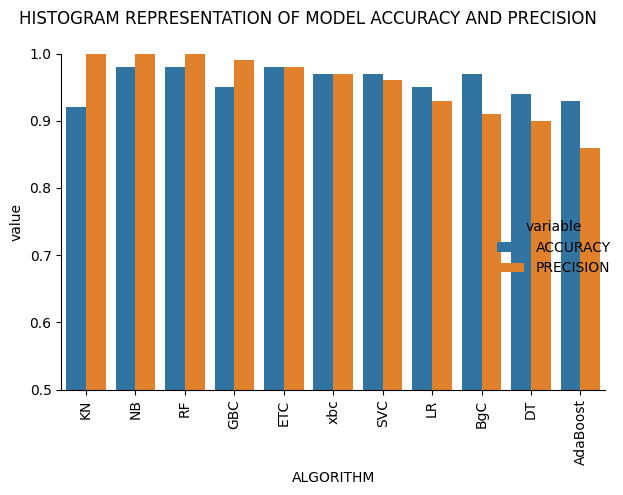

In [55]:
plt.figure(figsize=(18,7))

sns.catplot(x = 'ALGORITHM', y='value', hue = 'variable',data=performance, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.suptitle('HISTOGRAM REPRESENTATION OF MODEL ACCURACY AND PRECISION')
plt.tight_layout()
plt.show()